<a href="https://colab.research.google.com/github/AarnavSinghal/Customer-Segmentation/blob/main/Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Library Imports

In [1]:

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from matplotlib.colors import ListedColormap

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples

from scipy import stats

print('All libraries imported successfully ✓')

All libraries imported successfully ✓


##Data Loading

In [2]:
df = pd.read_csv('/content/marketing_campaign.csv', sep='\t')

print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

Shape: 2240 rows × 29 columns


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [4]:
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean','std'])

,count,mean,std,min,25%,50%,75%,max
ID,2240.000000,5592.159821,3246.662198,0.000000,2828.250000,5458.500000,8427.750000,11191.000000
Year_Birth,2240.000000,1968.805804,11.984069,1893.000000,1959.000000,1970.000000,1977.000000,1996.000000
Income,2216.000000,52247.251354,25173.076661,1730.000000,35303.000000,51381.500000,68522.000000,666666.000000
Kidhome,2240.000000,0.444196,0.538398,0.000000,0.000000,0.000000,1.000000,2.000000
Teenhome,2240.000000,0.506250,0.544538,0.000000,0.000000,0.000000,1.000000,2.000000
Recency,2240.000000,49.109375,28.962453,0.000000,24.000000,49.000000,74.000000,99.000000
MntWines,2240.000000,303.935714,336.597393,0.000000,23.750000,173.500000,504.250000,1493.000000
MntFruits,2240.000000,26.302232,39.773434,0.000000,1.000000,8.000000,33.000000,199.000000
MntMeatProducts,2240.000000,166.950000,225.715373,0.000000,16.000000,67.000000,232.000000,1725.000000
MntFishProducts,2240.000000,37.525446,54.628979,0.000000,3.000000,12.000000,50.000000,259.000000


In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print('Columns with missing values:')
print(missing)
print(f'\nTotal missing: {df.isnull().sum().sum()}')

Columns with missing values:
Income    24
dtype: int64

Total missing: 24


##Data Cleaning and Feature Engineering


In [6]:
df_clean = df.copy()

# 1. Drop missing Income rows (only ~24 rows)
df_clean.dropna(subset=['Income'], inplace=True)

# 2. Remove extreme Income outliers (beyond 3σ)
df_clean = df_clean[np.abs(stats.zscore(df_clean['Income'])) < 3]

# 3. Derive Age from Year_Birth
df_clean['Age'] = 2024 - df_clean['Year_Birth']
df_clean = df_clean[df_clean['Age'] < 90]  # remove clearly erroneous entries

# 4. Customer tenure in days
df_clean['Dt_Customer'] = pd.to_datetime(df_clean['Dt_Customer'], dayfirst=True)
df_clean['Days_As_Customer'] = (pd.Timestamp('2024-01-01') - df_clean['Dt_Customer']).dt.days

# 5. Total amount spent across all product categories
spend_cols = ['MntWines','MntFruits','MntMeatProducts',
              'MntFishProducts','MntSweetProducts','MntGoldProds']
df_clean['Total_Spend'] = df_clean[spend_cols].sum(axis=1)

# 6. Total number of purchases across all channels
purchase_cols = ['NumWebPurchases','NumCatalogPurchases','NumStorePurchases','NumDealsPurchases']
df_clean['Total_Purchases'] = df_clean[purchase_cols].sum(axis=1)

# 7. Total children at home
df_clean['Total_Children'] = df_clean['Kidhome'] + df_clean['Teenhome']

# 8. Total campaigns accepted
cmp_cols = ['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5','Response']
df_clean['Total_Campaigns_Accepted'] = df_clean[cmp_cols].sum(axis=1)

# 9. Simplify Marital_Status
df_clean['Living_With'] = df_clean['Marital_Status'].replace({
    'Married': 'Partner', 'Together': 'Partner',
    'Single': 'Alone', 'Divorced': 'Alone',
    'Widow': 'Alone', 'Absurd': 'Alone', 'YOLO': 'Alone'
})

# 10. Ordinal encode Education
edu_order = {'Basic': 0, '2n Cycle': 1, 'Graduation': 2, 'Master': 3, 'PhD': 4}
df_clean['Education_Level'] = df_clean['Education'].map(edu_order)

# 11. Avg spend per purchase (avoid div-by-zero)
df_clean['Avg_Spend_Per_Purchase'] = np.where(
    df_clean['Total_Purchases'] > 0,
    df_clean['Total_Spend'] / df_clean['Total_Purchases'],
    0
)

print(f'Clean dataset shape: {df_clean.shape}')
print('New features created: Age, Days_As_Customer, Total_Spend, Total_Purchases,',
      'Total_Children, Total_Campaigns_Accepted, Living_With, Education_Level, Avg_Spend_Per_Purchase')

Clean dataset shape: (2205, 38)
New features created: Age, Days_As_Customer, Total_Spend, Total_Purchases, Total_Children, Total_Campaigns_Accepted, Living_With, Education_Level, Avg_Spend_Per_Purchase


##EDA

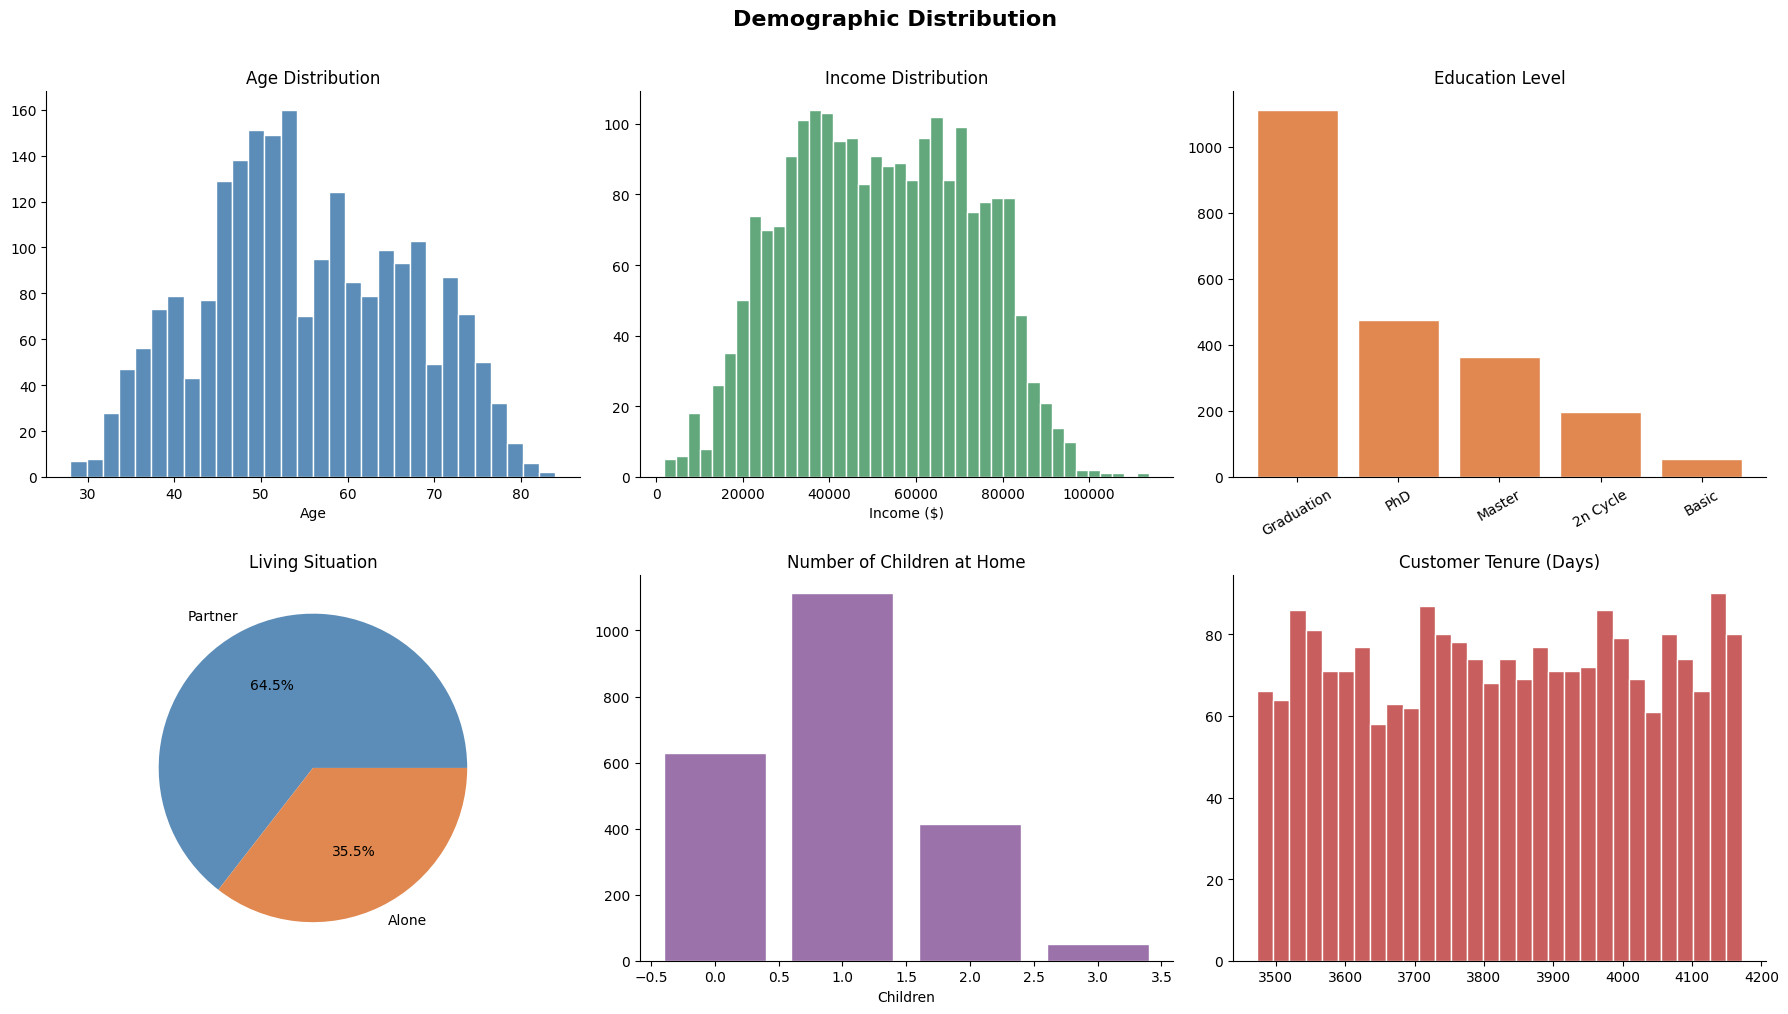

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Demographic Distribution', fontsize=16, fontweight='bold', y=1.01)

# Age
axes[0,0].hist(df_clean['Age'], bins=30, color='#5B8DB8', edgecolor='white')
axes[0,0].set_title('Age Distribution'); axes[0,0].set_xlabel('Age')

# Income
axes[0,1].hist(df_clean['Income'], bins=40, color='#62A87C', edgecolor='white')
axes[0,1].set_title('Income Distribution'); axes[0,1].set_xlabel('Income ($)')

# Education
edu_counts = df_clean['Education'].value_counts()
axes[0,2].bar(edu_counts.index, edu_counts.values, color='#E08850', edgecolor='white')
axes[0,2].set_title('Education Level'); axes[0,2].tick_params(axis='x', rotation=30)

# Marital Status (simplified)
living = df_clean['Living_With'].value_counts()
axes[1,0].pie(living.values, labels=living.index, autopct='%1.1f%%',
              colors=['#5B8DB8','#E08850'])
axes[1,0].set_title('Living Situation')

# Total Children
child_counts = df_clean['Total_Children'].value_counts().sort_index()
axes[1,1].bar(child_counts.index, child_counts.values, color='#9B72AA', edgecolor='white')
axes[1,1].set_title('Number of Children at Home'); axes[1,1].set_xlabel('Children')

# Customer Tenure
axes[1,2].hist(df_clean['Days_As_Customer'], bins=30, color='#C95E5E', edgecolor='white')
axes[1,2].set_title('Customer Tenure (Days)')

plt.tight_layout()
plt.savefig('eda_demographic.png', dpi=150, bbox_inches='tight')
plt.show()

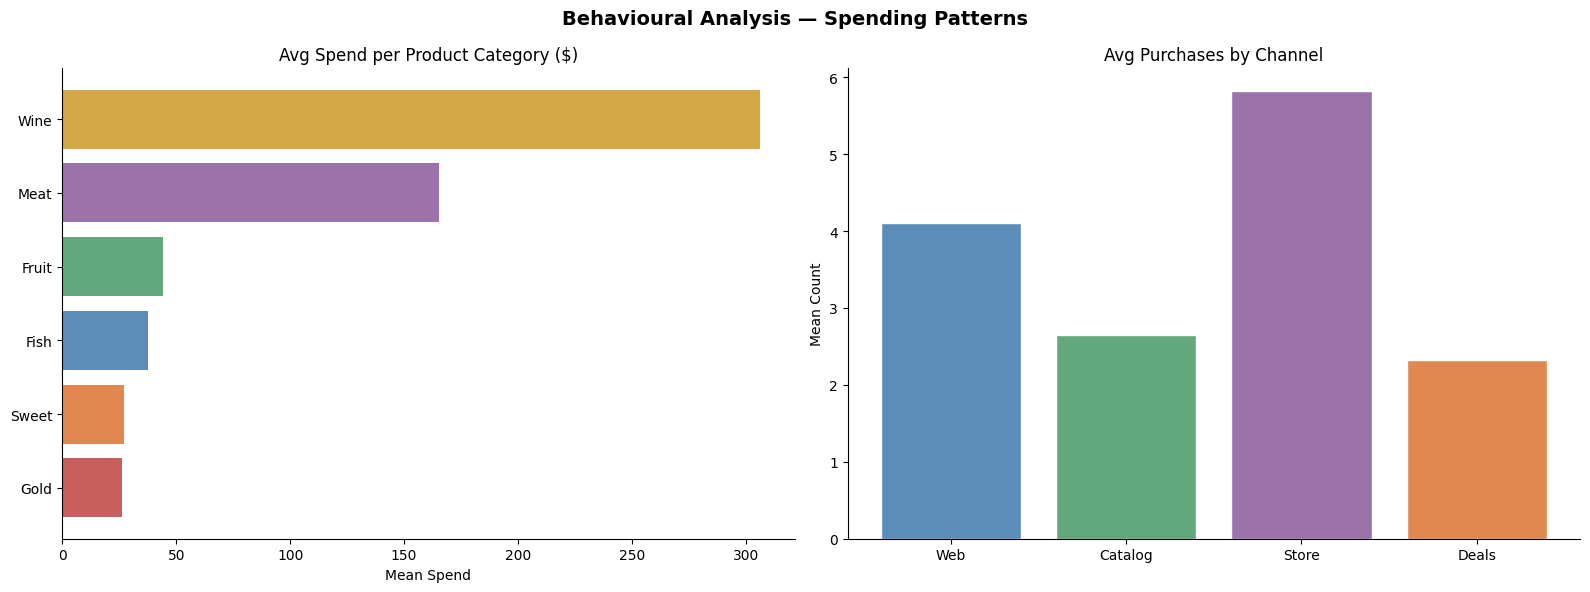

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Behavioural Analysis — Spending Patterns', fontsize=14, fontweight='bold')

# Spending by category
spend_means = df_clean[spend_cols].mean().sort_values(ascending=True)
spend_means.index = ['Gold','Sweet','Fish','Fruit','Meat','Wine']
axes[0].barh(spend_means.index, spend_means.values,
             color=['#C95E5E','#E08850','#5B8DB8','#62A87C','#9B72AA','#D4A847'])
axes[0].set_title('Avg Spend per Product Category ($)')
axes[0].set_xlabel('Mean Spend')

# Purchase channels
channel_means = df_clean[['NumWebPurchases','NumCatalogPurchases',
                           'NumStorePurchases','NumDealsPurchases']].mean()
channel_means.index = ['Web','Catalog','Store','Deals']
axes[1].bar(channel_means.index, channel_means.values,
            color=['#5B8DB8','#62A87C','#9B72AA','#E08850'], edgecolor='white')
axes[1].set_title('Avg Purchases by Channel')
axes[1].set_ylabel('Mean Count')

plt.tight_layout()
plt.savefig('eda_behaviour.png', dpi=150, bbox_inches='tight')
plt.show()

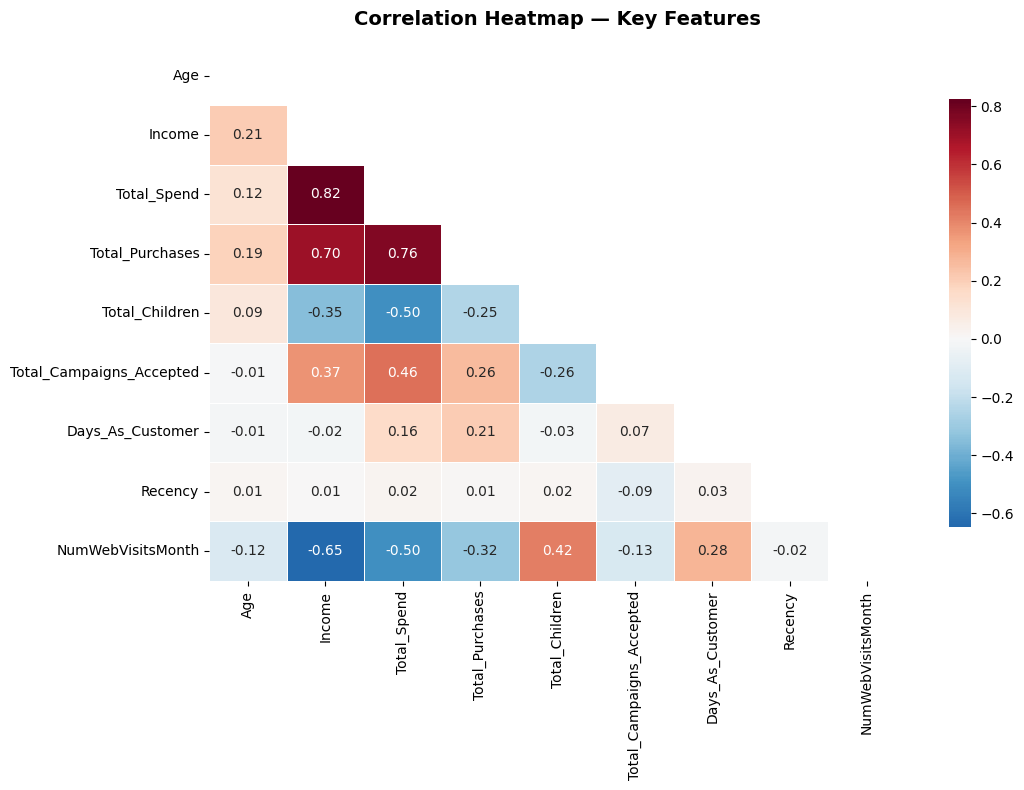

In [9]:
# Correlation heatmap of key numeric features
corr_cols = ['Age','Income','Total_Spend','Total_Purchases','Total_Children',
             'Total_Campaigns_Accepted','Days_As_Customer','Recency','NumWebVisitsMonth']
corr_matrix = df_clean[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, mask=mask, ax=ax, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap — Key Features', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

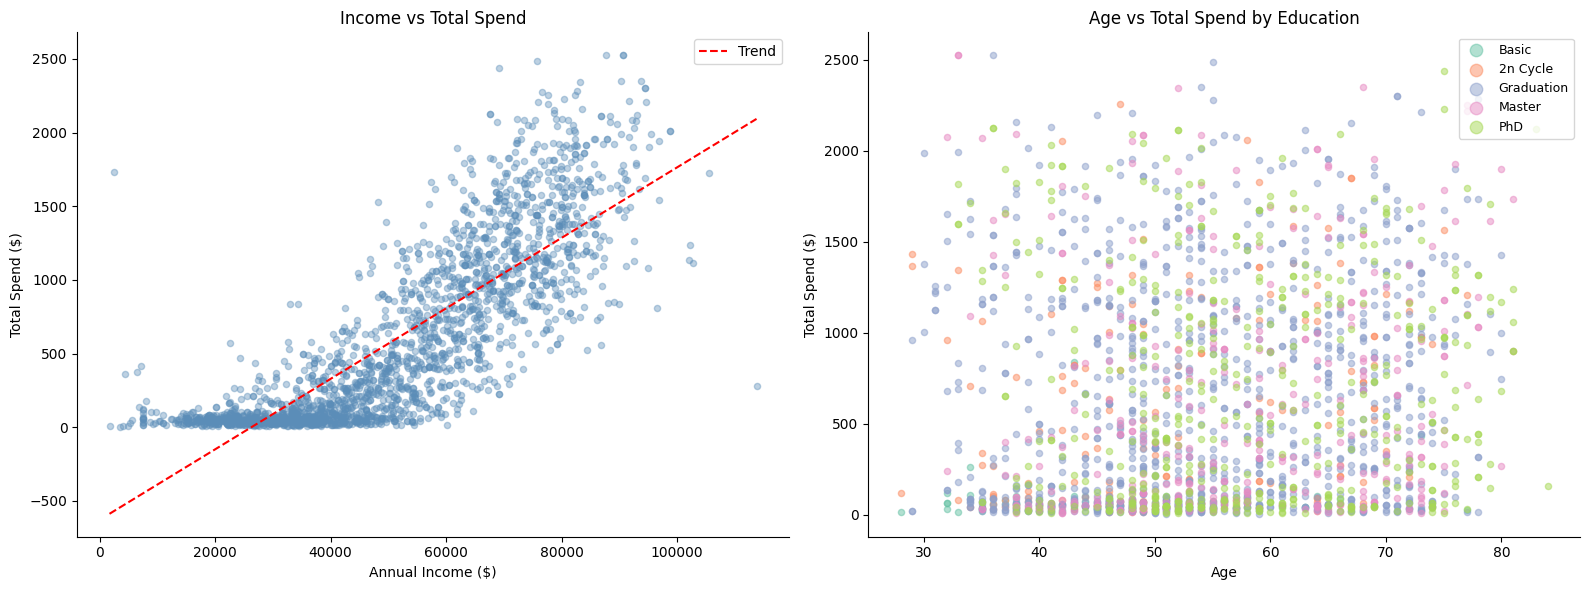

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Income vs Total Spend
axes[0].scatter(df_clean['Income'], df_clean['Total_Spend'],
                alpha=0.4, color='#5B8DB8', s=20)
z = np.polyfit(df_clean['Income'], df_clean['Total_Spend'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_clean['Income'].min(), df_clean['Income'].max(), 100)
axes[0].plot(x_line, p(x_line), 'r--', lw=1.5, label=f'Trend')
axes[0].set_xlabel('Annual Income ($)'); axes[0].set_ylabel('Total Spend ($)')
axes[0].set_title('Income vs Total Spend'); axes[0].legend()

# Age vs Total Spend coloured by Education
for i, edu in enumerate(['Basic','2n Cycle','Graduation','Master','PhD']):
    subset = df_clean[df_clean['Education'] == edu]
    axes[1].scatter(subset['Age'], subset['Total_Spend'],
                    alpha=0.5, label=edu, s=20)
axes[1].set_xlabel('Age'); axes[1].set_ylabel('Total Spend ($)')
axes[1].set_title('Age vs Total Spend by Education')
axes[1].legend(markerscale=2, fontsize=9)

plt.tight_layout()
plt.savefig('income_spend_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

##Feature Selection and Preprocessing

In [11]:
# Select features covering all three dimensions
features = [
    # Demographic
    'Age', 'Income', 'Education_Level', 'Total_Children', 'Days_As_Customer',
    # Behavioural
    'Total_Spend', 'Total_Purchases', 'MntWines', 'MntMeatProducts',
    'NumWebPurchases', 'NumStorePurchases', 'NumDealsPurchases',
    'Avg_Spend_Per_Purchase', 'Recency', 'NumWebVisitsMonth',
    # Psychological (campaign response = brand persuasibility)
    'Total_Campaigns_Accepted'
]

# Binary encode Living_With
df_clean['Is_Partner'] = (df_clean['Living_With'] == 'Partner').astype(int)
features.append('Is_Partner')

X = df_clean[features].copy()

# Standard scale all features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Feature matrix shape: {X_scaled.shape}')
print(f'Features used ({len(features)}): {features}')

Feature matrix shape: (2205, 17)
Features used (17): ['Age', 'Income', 'Education_Level', 'Total_Children', 'Days_As_Customer', 'Total_Spend', 'Total_Purchases', 'MntWines', 'MntMeatProducts', 'NumWebPurchases', 'NumStorePurchases', 'NumDealsPurchases', 'Avg_Spend_Per_Purchase', 'Recency', 'NumWebVisitsMonth', 'Total_Campaigns_Accepted', 'Is_Partner']


##Dimention reduction using PCA

PCA Results:
  PC1: 38.43% variance  |  Cumulative: 38.43%
  PC2: 12.44% variance  |  Cumulative: 50.86%
  PC3: 7.93% variance  |  Cumulative: 58.80%


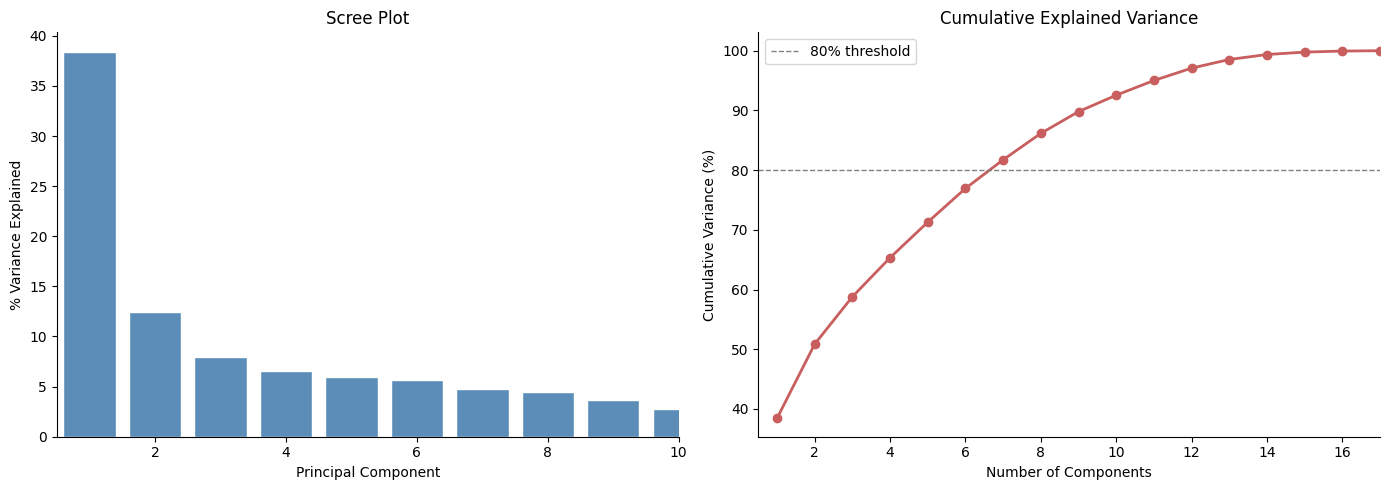

In [12]:
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_ * 100
cumulative = np.cumsum(explained)

print('PCA Results:')
for i, (e, c) in enumerate(zip(explained, cumulative)):
    print(f'  PC{i+1}: {e:.2f}% variance  |  Cumulative: {c:.2f}%')

# Scree plot
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
n_components = len(pca_full.explained_variance_ratio_)

axes[0].bar(range(1, n_components+1),
            pca_full.explained_variance_ratio_*100,
            color='#5B8DB8', edgecolor='white')
axes[0].set_xlabel('Principal Component'); axes[0].set_ylabel('% Variance Explained')
axes[0].set_title('Scree Plot'); axes[0].set_xlim(0.5, 10)

axes[1].plot(range(1, n_components+1),
             np.cumsum(pca_full.explained_variance_ratio_)*100,
             marker='o', color='#C95E5E', lw=2)
axes[1].axhline(80, ls='--', color='gray', lw=1, label='80% threshold')
axes[1].set_xlabel('Number of Components'); axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend(); axes[1].set_xlim(0.5, n_components)

plt.tight_layout()
plt.savefig('pca_scree.png', dpi=150, bbox_inches='tight')
plt.show()

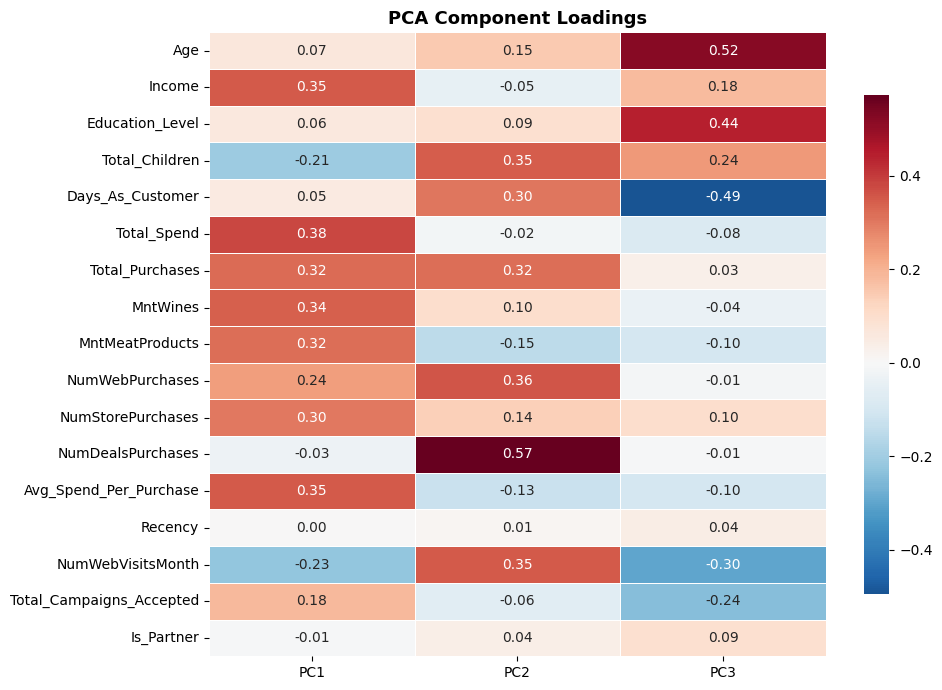


Top contributors to PC1 (absolute loadings):
Total_Spend               0.379
Avg_Spend_Per_Purchase    0.348
Income                    0.348
MntWines                  0.343
Total_Purchases           0.323
Name: PC1, dtype: float64


In [13]:
# PCA Loadings — which features drive each component
loadings = pd.DataFrame(
    pca.components_.T,
    index=features,
    columns=['PC1','PC2','PC3']
).round(3)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('PCA Component Loadings', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pca_loadings.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop contributors to PC1 (absolute loadings):')
print(loadings['PC1'].abs().sort_values(ascending=False).head(5))

##Optimal K selection: Elbow method and Silhouette Score

K=2  |  Inertia: 10704.6  |  Silhouette: 0.4519
K=3  |  Inertia: 7554.1  |  Silhouette: 0.4044
K=4  |  Inertia: 6479.9  |  Silhouette: 0.3129
K=5  |  Inertia: 5570.9  |  Silhouette: 0.2996
K=6  |  Inertia: 4816.9  |  Silhouette: 0.2984
K=7  |  Inertia: 4368.1  |  Silhouette: 0.2889
K=8  |  Inertia: 4064.1  |  Silhouette: 0.2830
K=9  |  Inertia: 3809.0  |  Silhouette: 0.2552
K=10  |  Inertia: 3567.6  |  Silhouette: 0.2551


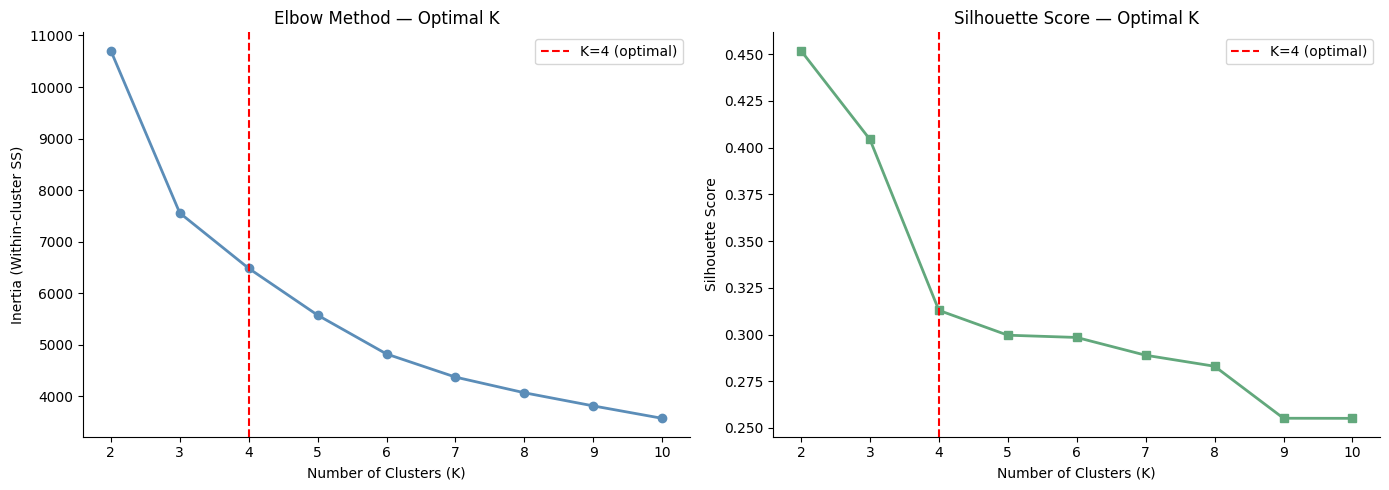

In [14]:
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels))
    print(f'K={k}  |  Inertia: {km.inertia_:.1f}  |  Silhouette: {silhouette_score(X_pca, labels):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(list(K_range), inertias, marker='o', color='#5B8DB8', lw=2)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (Within-cluster SS)')
axes[0].set_title('Elbow Method — Optimal K')
axes[0].axvline(x=4, color='red', ls='--', lw=1.5, label='K=4 (optimal)')
axes[0].legend()

# Silhouette
axes[1].plot(list(K_range), silhouettes, marker='s', color='#62A87C', lw=2)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score — Optimal K')
axes[1].axvline(x=4, color='red', ls='--', lw=1.5, label='K=4 (optimal)')
axes[1].legend()

plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

##K means clustering

In [15]:
OPTIMAL_K = 4

kmeans = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=20, random_state=42)
df_clean['Cluster'] = kmeans.fit_predict(X_pca)

final_sil = silhouette_score(X_pca, df_clean['Cluster'])
print(f'Final Silhouette Score (K={OPTIMAL_K}): {final_sil:.4f}')
print(f'\nCluster sizes:')
print(df_clean['Cluster'].value_counts().sort_index())

Final Silhouette Score (K=4): 0.3129

Cluster sizes:
Cluster
0    515
1    599
2    507
3    584
Name: count, dtype: int64


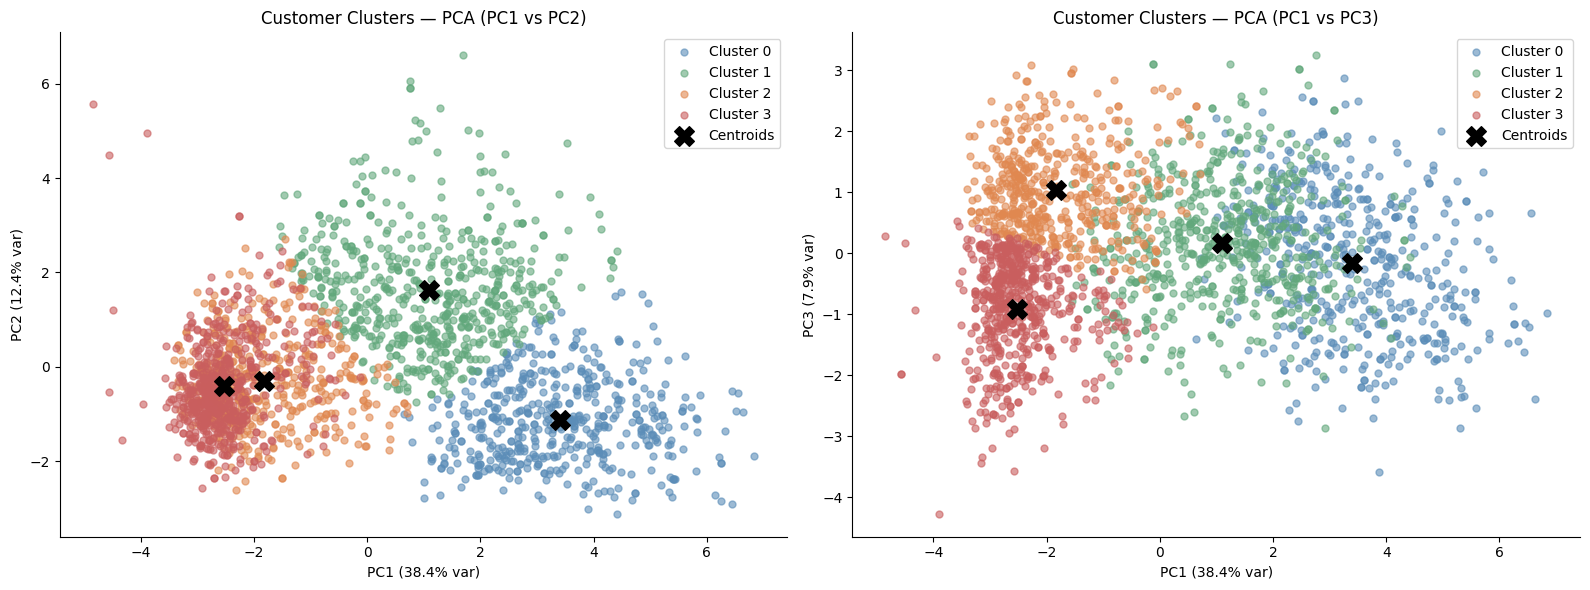

In [16]:
# 2D PCA scatter — PC1 vs PC2
CLUSTER_COLORS = ['#5B8DB8', '#62A87C', '#E08850', '#C95E5E']
CLUSTER_NAMES  = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for c in range(OPTIMAL_K):
    mask = df_clean['Cluster'] == c
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=CLUSTER_COLORS[c], label=CLUSTER_NAMES[c], alpha=0.6, s=25)

# Plot centroids
centroids_pca = kmeans.cluster_centers_
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1],
                c='black', marker='X', s=200, zorder=5, label='Centroids')
axes[0].set_xlabel(f'PC1 ({explained[0]:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({explained[1]:.1f}% var)')
axes[0].set_title('Customer Clusters — PCA (PC1 vs PC2)')
axes[0].legend()

# PC1 vs PC3
for c in range(OPTIMAL_K):
    mask = df_clean['Cluster'] == c
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 2],
                    c=CLUSTER_COLORS[c], label=CLUSTER_NAMES[c], alpha=0.6, s=25)
axes[1].scatter(centroids_pca[:, 0], centroids_pca[:, 2],
                c='black', marker='X', s=200, zorder=5, label='Centroids')
axes[1].set_xlabel(f'PC1 ({explained[0]:.1f}% var)')
axes[1].set_ylabel(f'PC3 ({explained[2]:.1f}% var)')
axes[1].set_title('Customer Clusters — PCA (PC1 vs PC3)')
axes[1].legend()

plt.tight_layout()
plt.savefig('cluster_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

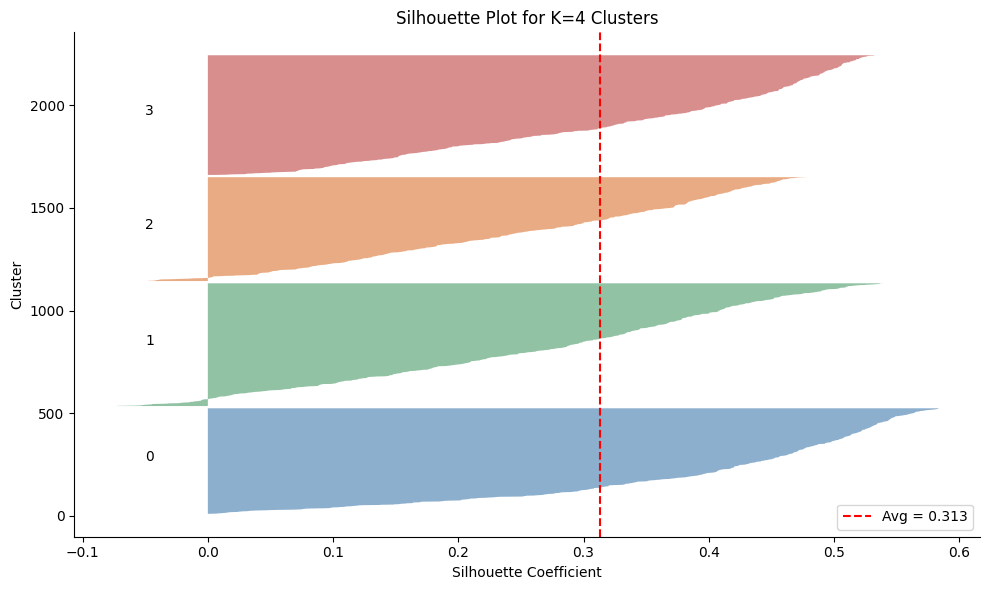

In [17]:
# Silhouette plot per cluster
sil_vals = silhouette_samples(X_pca, df_clean['Cluster'])
fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10

for c in range(OPTIMAL_K):
    c_sil = np.sort(sil_vals[df_clean['Cluster'] == c])
    size = c_sil.shape[0]
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, c_sil,
                     facecolor=CLUSTER_COLORS[c], alpha=0.7)
    ax.text(-0.05, y_lower + 0.5*size, str(c), fontsize=10)
    y_lower = y_upper + 10

ax.axvline(x=final_sil, color='red', ls='--', lw=1.5, label=f'Avg = {final_sil:.3f}')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster')
ax.set_title('Silhouette Plot for K=4 Clusters')
ax.legend()
plt.tight_layout()
plt.savefig('silhouette_plot.png', dpi=150, bbox_inches='tight')
plt.show()

##Cluster Profiling

In [18]:
profile_cols = [
    'Age','Income','Education_Level','Total_Children',
    'Total_Spend','Total_Purchases','Avg_Spend_Per_Purchase',
    'Total_Campaigns_Accepted','Recency','NumWebVisitsMonth'
]

profile = df_clean.groupby('Cluster')[profile_cols].mean().round(2)
profile.index = [f'Cluster {i}' for i in profile.index]
print('=== Cluster Profiles (Mean Values) ===')
print(profile.T.to_string())

=== Cluster Profiles (Mean Values) ===
                          Cluster 0  Cluster 1  Cluster 2  Cluster 3
Age                           55.39      58.76      59.67      47.10
Income                     77028.12   58746.67   43760.28   28735.47
Education_Level                2.49       2.63       2.87       1.89
Total_Children                 0.13       1.17       1.45       1.01
Total_Spend                 1423.39     799.76     146.03      88.86
Total_Purchases               20.24      22.20       9.32       7.50
Avg_Spend_Per_Purchase        72.68      35.69      13.30      10.81
Total_Campaigns_Accepted       1.12       0.39       0.11       0.22
Recency                       49.37      48.64      49.96      48.24
NumWebVisitsMonth              2.66       5.86       5.36       7.14


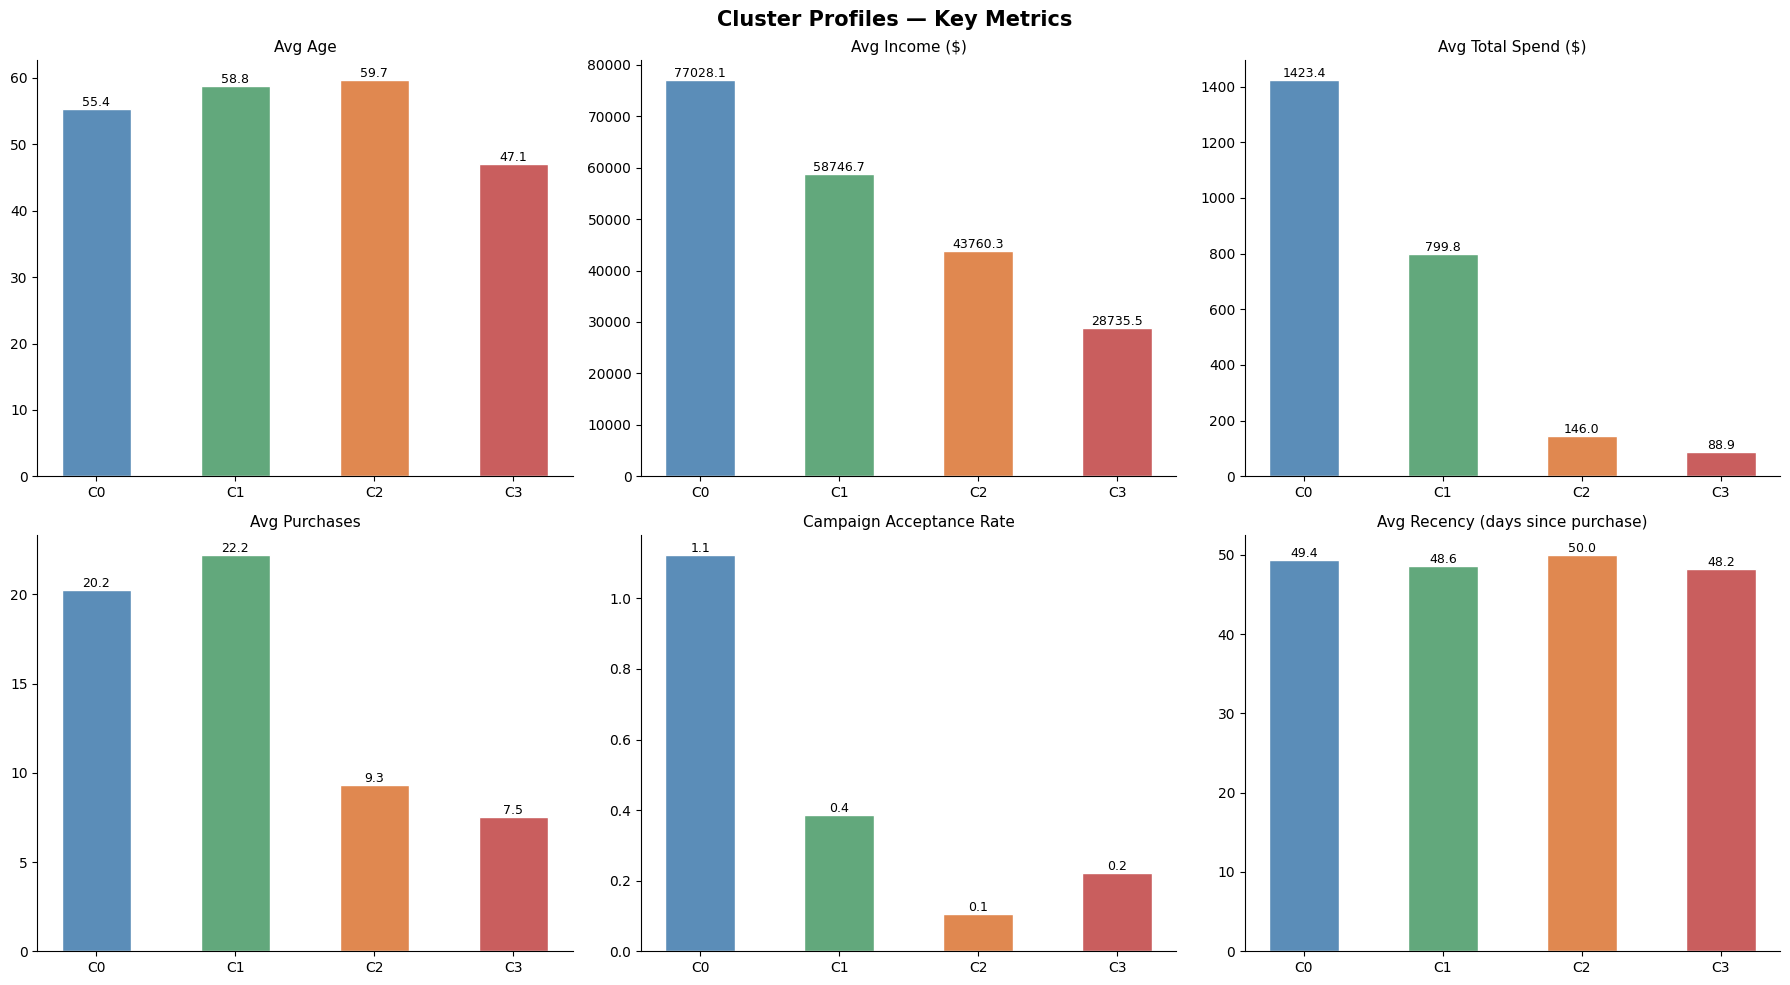

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Cluster Profiles — Key Metrics', fontsize=15, fontweight='bold')

metrics = [
    ('Age', 'Avg Age'),
    ('Income', 'Avg Income ($)'),
    ('Total_Spend', 'Avg Total Spend ($)'),
    ('Total_Purchases', 'Avg Purchases'),
    ('Total_Campaigns_Accepted', 'Campaign Acceptance Rate'),
    ('Recency', 'Avg Recency (days since purchase)')
]

for ax, (col, label) in zip(axes.flatten(), metrics):
    vals = df_clean.groupby('Cluster')[col].mean()
    bars = ax.bar([f'C{i}' for i in vals.index], vals.values,
                  color=CLUSTER_COLORS, edgecolor='white', width=0.5)
    ax.bar_label(bars, fmt='%.1f', fontsize=9)
    ax.set_title(label, fontsize=11)
    ax.set_ylabel('')

plt.tight_layout()
plt.savefig('cluster_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

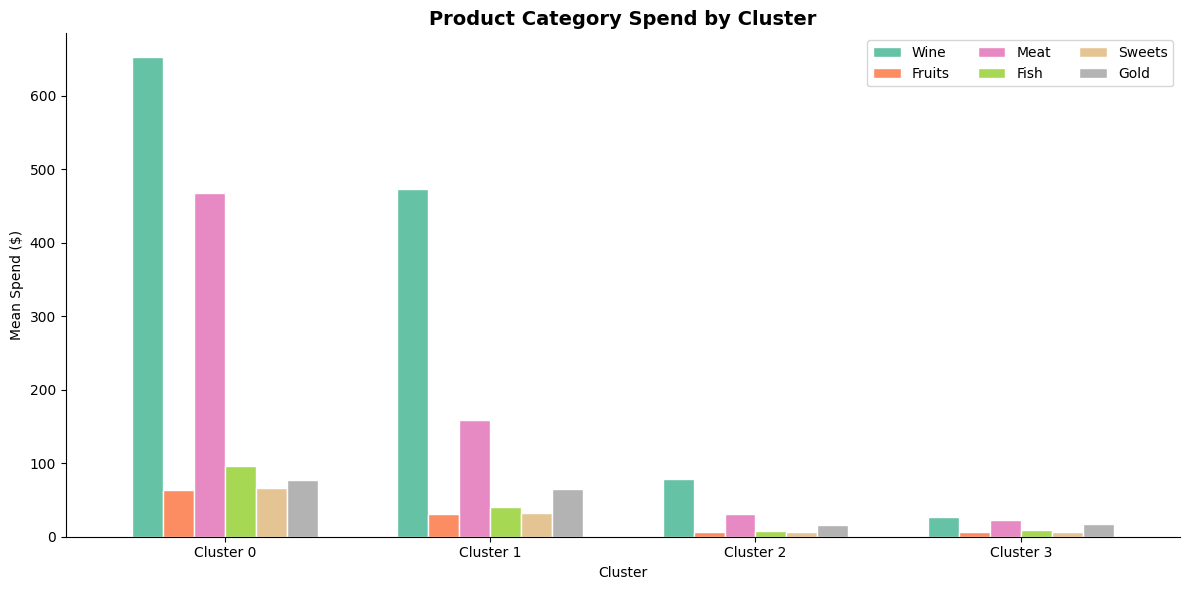

In [20]:
# Spending breakdown by product category per cluster
spend_by_cluster = df_clean.groupby('Cluster')[spend_cols].mean()
spend_by_cluster.index = [f'Cluster {i}' for i in spend_by_cluster.index]
spend_by_cluster.columns = ['Wine','Fruits','Meat','Fish','Sweets','Gold']

spend_by_cluster.plot(kind='bar', figsize=(12, 6), edgecolor='white',
                      colormap='Set2', width=0.7)
plt.title('Product Category Spend by Cluster', fontsize=14, fontweight='bold')
plt.xlabel('Cluster'); plt.ylabel('Mean Spend ($)')
plt.xticks(rotation=0)
plt.legend(loc='upper right', ncol=3)
plt.tight_layout()
plt.savefig('spend_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

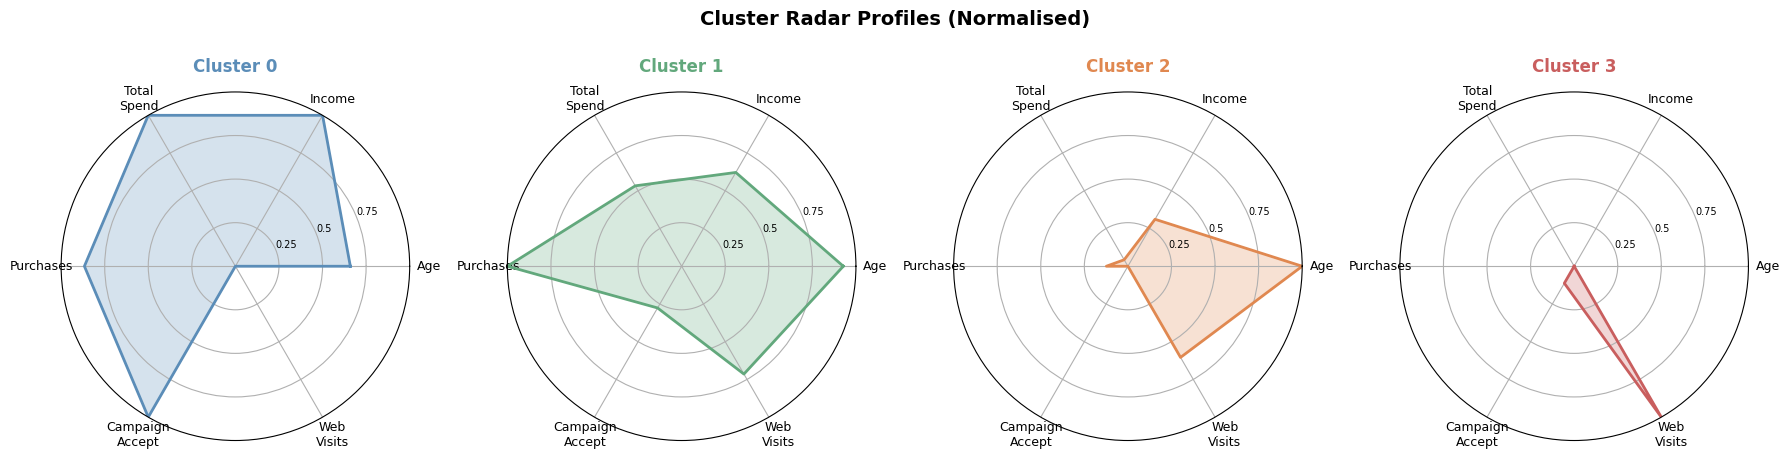

In [21]:
# Radar/Spider chart — normalised cluster profiles
from matplotlib.patches import FancyArrowPatch

radar_cols = ['Age','Income','Total_Spend','Total_Purchases',
              'Total_Campaigns_Accepted','NumWebVisitsMonth']
radar_labels = ['Age','Income','Total\nSpend','Purchases','Campaign\nAccept','Web\nVisits']

# Normalise 0-1
radar_data = df_clean.groupby('Cluster')[radar_cols].mean()
radar_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min())

N = len(radar_cols)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, axes = plt.subplots(1, OPTIMAL_K, figsize=(18, 5), subplot_kw=dict(polar=True))
fig.suptitle('Cluster Radar Profiles (Normalised)', fontsize=14, fontweight='bold')

for idx, ax in enumerate(axes):
    vals = radar_norm.iloc[idx].tolist()
    vals += vals[:1]
    ax.plot(angles, vals, color=CLUSTER_COLORS[idx], lw=2)
    ax.fill(angles, vals, color=CLUSTER_COLORS[idx], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75])
    ax.set_yticklabels(['0.25','0.5','0.75'], fontsize=7)
    ax.set_title(f'Cluster {idx}', color=CLUSTER_COLORS[idx],
                 fontsize=12, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('radar_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

##RFM Analysis (Recency, Frequency, Monetary)

In [22]:
# RFM scoring
rfm = df_clean[['Cluster','Recency','Total_Purchases','Total_Spend']].copy()
rfm.columns = ['Cluster','Recency','Frequency','Monetary']

# Bin into quintiles (5 = best)
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1]).astype(int)  # Lower recency = better
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

def rfm_segment(score):
    if score >= 13: return 'Champions'
    elif score >= 10: return 'Loyal Customers'
    elif score >= 7:  return 'Potential Loyalists'
    elif score >= 5:  return 'At Risk'
    else:             return 'Lost Customers'

rfm['RFM_Segment'] = rfm['RFM_Score'].apply(rfm_segment)

print('RFM Segment Distribution:')
print(rfm['RFM_Segment'].value_counts())
print('\nRFM by K-Means Cluster:')
print(rfm.groupby('Cluster')[['Recency','Frequency','Monetary','RFM_Score']].mean().round(2))

RFM Segment Distribution:
RFM_Segment
Loyal Customers        698
Potential Loyalists    651
At Risk                361
Champions              327
Lost Customers         168
Name: count, dtype: int64

RFM by K-Means Cluster:
         Recency  Frequency  Monetary  RFM_Score
Cluster                                         
0          49.37      20.24   1423.39      11.71
1          48.64      22.20    799.76      11.08
2          49.96       9.32    146.03       6.92
3          48.24       7.50     88.86       6.33


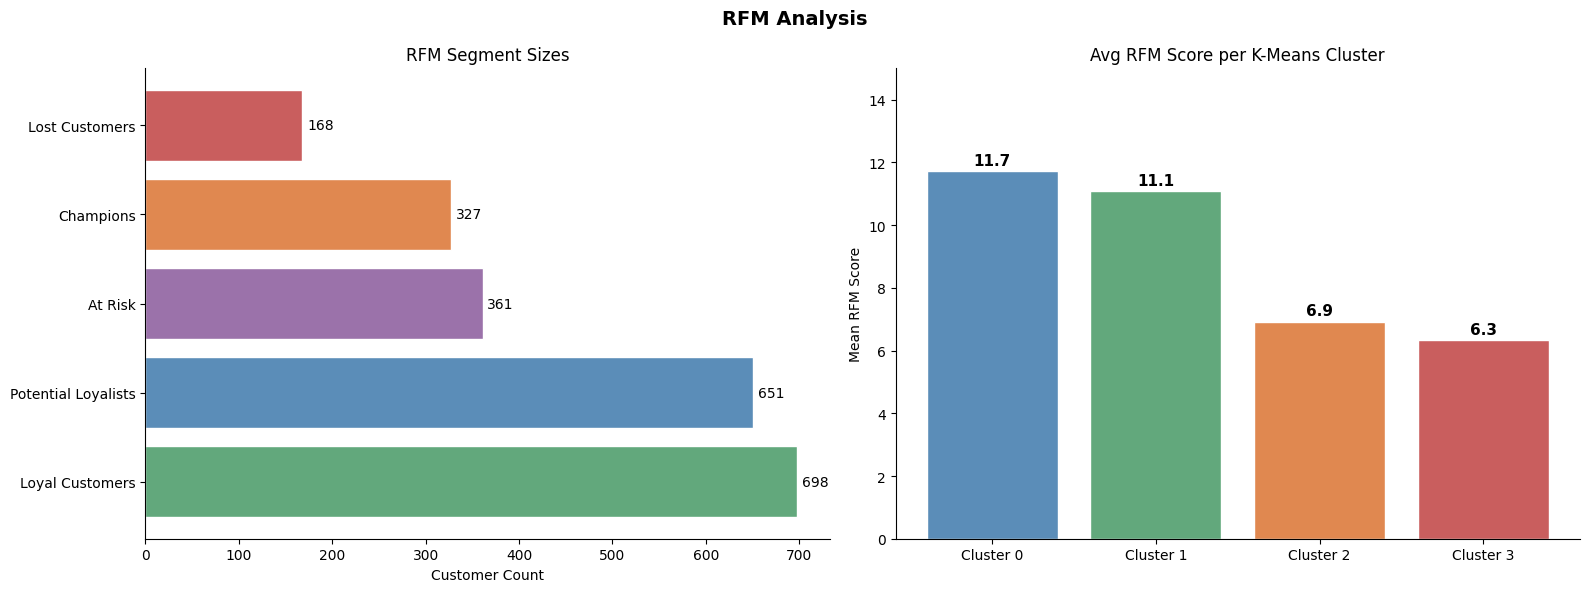

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('RFM Analysis', fontsize=14, fontweight='bold')

# RFM Segment distribution
seg_counts = rfm['RFM_Segment'].value_counts()
seg_colors = ['#62A87C','#5B8DB8','#9B72AA','#E08850','#C95E5E']
axes[0].barh(seg_counts.index, seg_counts.values,
             color=seg_colors[:len(seg_counts)], edgecolor='white')
axes[0].set_title('RFM Segment Sizes')
axes[0].set_xlabel('Customer Count')
for i, v in enumerate(seg_counts.values):
    axes[0].text(v+5, i, str(v), va='center', fontsize=10)

# Avg RFM Score by K-Means cluster
rfm_cluster = rfm.groupby('Cluster')['RFM_Score'].mean()
axes[1].bar([f'Cluster {i}' for i in rfm_cluster.index],
            rfm_cluster.values, color=CLUSTER_COLORS, edgecolor='white')
axes[1].set_title('Avg RFM Score per K-Means Cluster')
axes[1].set_ylabel('Mean RFM Score')
axes[1].set_ylim(0, 15)
for i, v in enumerate(rfm_cluster.values):
    axes[1].text(i, v+0.2, f'{v:.1f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('rfm_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

##Segment naming and Marketing Recommendations

In [24]:
# Map cluster IDs to persona names (will vary — review profile output above to adjust)
SEGMENT_NAMES = {
    0: 'Budget Conscious',
    1: 'Affluent Loyalists',
    2: 'Moderate Mainstream',
    3: 'Deal Seekers'
}

df_clean['Segment_Name'] = df_clean['Cluster'].map(SEGMENT_NAMES)

print('Final segment assignment:')
print(df_clean['Segment_Name'].value_counts())
print('\nFull profile summary:')
summary = df_clean.groupby('Segment_Name')[profile_cols].mean().round(1)
print(summary.T)

Final segment assignment:
Segment_Name
Affluent Loyalists     599
Deal Seekers           584
Budget Conscious       515
Moderate Mainstream    507
Name: count, dtype: int64

Full profile summary:
Segment_Name              Affluent Loyalists  Budget Conscious  Deal Seekers  \
Age                                     58.8              55.4          47.1   
Income                               58746.7           77028.1       28735.5   
Education_Level                          2.6               2.5           1.9   
Total_Children                           1.2               0.1           1.0   
Total_Spend                            799.8            1423.4          88.9   
Total_Purchases                         22.2              20.2           7.5   
Avg_Spend_Per_Purchase                  35.7              72.7          10.8   
Total_Campaigns_Accepted                 0.4               1.1           0.2   
Recency                                 48.6              49.4          48.2   
NumW

In [25]:
recommendations = {
    'Budget Conscious': {
        'Channel': 'Social Media, SMS',
        'Message': 'Value deals, EMI options, seasonal discounts',
        'Product': 'Economy packs, private labels',
        'Retention': 'Loyalty points, cashback programs'
    },
    'Affluent Loyalists': {
        'Channel': 'Email, Premium catalog, App notifications',
        'Message': 'Exclusive access, premium quality assurance',
        'Product': 'Premium wines, meat, high-end goods',
        'Retention': 'VIP membership, early product access, concierge service'
    },
    'Moderate Mainstream': {
        'Channel': 'Web, Email, In-store',
        'Message': 'Balanced quality-value proposition',
        'Product': 'Mid-tier product bundles',
        'Retention': 'Referral programs, cross-sell complementary items'
    },
    'Deal Seekers': {
        'Channel': 'Email blasts, Retargeting ads',
        'Message': 'Flash sales, limited-time offers, BOGO deals',
        'Product': 'Clearance items, discount bundles',
        'Retention': 'Re-engagement campaigns, win-back discounts'
    }
}

print('='*60)
print('MARKETING STRATEGY RECOMMENDATIONS BY SEGMENT')
print('='*60)
for seg, rec in recommendations.items():
    print(f'\n▶ {seg}')
    for k, v in rec.items():
        print(f'   {k:12s}: {v}')

MARKETING STRATEGY RECOMMENDATIONS BY SEGMENT

▶ Budget Conscious
   Channel     : Social Media, SMS
   Message     : Value deals, EMI options, seasonal discounts
   Product     : Economy packs, private labels
   Retention   : Loyalty points, cashback programs

▶ Affluent Loyalists
   Channel     : Email, Premium catalog, App notifications
   Message     : Exclusive access, premium quality assurance
   Product     : Premium wines, meat, high-end goods
   Retention   : VIP membership, early product access, concierge service

▶ Moderate Mainstream
   Channel     : Web, Email, In-store
   Message     : Balanced quality-value proposition
   Product     : Mid-tier product bundles
   Retention   : Referral programs, cross-sell complementary items

▶ Deal Seekers
   Channel     : Email blasts, Retargeting ads
   Message     : Flash sales, limited-time offers, BOGO deals
   Product     : Clearance items, discount bundles
   Retention   : Re-engagement campaigns, win-back discounts


In [26]:
# Export segmented dataset
export_cols = ['ID','Age','Income','Education','Marital_Status',
               'Total_Spend','Total_Purchases','Total_Campaigns_Accepted',
               'Recency','Cluster','Segment_Name']

df_export = df_clean[[c for c in export_cols if c in df_clean.columns]]
df_export.to_csv('customer_segments_output.csv', index=False)
print(f'Exported {len(df_export)} records to customer_segments_output.csv')
print('\nFinal dataset preview:')
df_export.head(10)

Exported 2205 records to customer_segments_output.csv

Final dataset preview:


,ID,Age,Income,Education,Marital_Status,Total_Spend,Total_Purchases,Total_Campaigns_Accepted,Recency,Cluster,Segment_Name
0,5524,67,58138.0,Graduation,Single,1617,25,1,58,0,Budget Conscious
1,2174,70,46344.0,Graduation,Single,27,6,0,38,2,Moderate Mainstream
2,4141,59,71613.0,Graduation,Together,776,21,0,26,1,Affluent Loyalists
3,6182,40,26646.0,Graduation,Together,53,8,0,26,3,Deal Seekers
4,5324,43,58293.0,PhD,Married,422,19,0,94,1,Affluent Loyalists
5,7446,57,62513.0,Master,Together,716,22,0,16,1,Affluent Loyalists
6,965,53,55635.0,Graduation,Divorced,590,21,0,34,1,Affluent Loyalists
7,6177,39,33454.0,PhD,Married,169,10,0,32,3,Deal Seekers
8,4855,50,30351.0,PhD,Together,46,6,1,19,3,Deal Seekers
9,5899,74,5648.0,PhD,Together,49,2,1,68,3,Deal Seekers
